In [51]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

torch.__version__

'2.9.1+cpu'

In [11]:
train_dataset = datasets.CIFAR10 ( root = "./data", train = True, download = True )
test_dataset = datasets.CIFAR10 ( root = "./data", train = False, download = True )

100.0%


### Make sure to convert to tensor after loading!!

In [52]:
train_loader = DataLoader ( train_dataset, batch_size = 64, shuffle = True )
test_loader = DataLoader ( test_dataset, batch_size = 64, shuffle = True )

train_dataset.transform = transforms.ToTensor()
test_dataset.transform = transforms.ToTensor()

In [53]:
images, labels = next ( iter ( train_loader ) )
print ( images.shape )
print ( labels.shape )

print ( torch.min ( images ) )
print ( torch.max ( images ) )

print ( torch.min ( labels ) )
print ( torch.max ( labels ) )

torch.Size([64, 3, 32, 32])
torch.Size([64])
tensor(0.)
tensor(1.)
tensor(0)
tensor(9)


### The actual model..did conv2d, batchnorm, maxpool, dropout layers..

In [54]:
import torch.nn as nn
import torch.nn.functional as F

class MainModel ( nn.Module ):
    def __init__ ( self ):
        super().__init__()

        self.features = nn.Sequential (
            nn.Conv2d ( 3, 32, 3, padding = 1 ),
            nn.BatchNorm2d ( 32 ),
            nn.ReLU(),
            nn.MaxPool2d ( 2 ),

            nn.Conv2d ( 32, 64, 3, padding = 1 ),
            nn.BatchNorm2d ( 64 ),
            nn.ReLU(),
            nn.MaxPool2d ( 2 ),

            nn.Conv2d ( 64, 128, 3, padding = 1 ),
            nn.BatchNorm2d ( 128 ),
            nn.ReLU(),
            nn.MaxPool2d ( 2 ),
        )

        self.classifier = nn.Sequential (
            
            nn.Dropout ( 0.5 ),
            nn.Linear ( 128 * 4 * 4, 256 ),
            nn.ReLU(),
            
            nn.Dropout ( 0.5 ),
            nn.Linear ( 256, 10 )
        )

    def forward ( self, x ):
        x = self.features ( x )
        x = torch.flatten ( x, 1 )
        return self.classifier ( x )


In [55]:
model = MainModel()
loss = nn.CrossEntropyLoss()
opt = torch.optim.Adam ( model.parameters(), lr = 0.001 )

### valdiation split!! Much more complicated than tensorflow..

In [56]:
from torch.utils.data import random_split, DataLoader

val_ratio = 0.2
total_samples = len ( train_dataset )
val_size = int ( val_ratio * total_samples )
train_size = total_samples - val_size

train_subset, val_subset = random_split ( train_dataset, [train_size, val_size] )

train_loader = DataLoader ( train_subset, batch_size = 64, shuffle = True )
val_loader = DataLoader ( val_subset, batch_size = 64, shuffle = False )

In [57]:
total_epochs = 30

epoch_plot = []
train_loss_plot = []
val_loss_plot = []

scheduler = torch.optim.lr_scheduler.StepLR ( opt, step_size = 5, gamma = 0.5 )

for epoch in range ( total_epochs ):
    total_loss = 0.0
    total_labels = 0
    model.train()

    for images, labels in train_loader:
        
        outputs = model ( images )
        loss_back = loss ( outputs, labels )

        opt.zero_grad()
        loss_back.backward()
        opt.step()

        total_loss += loss_back.item() * images.size ( 0 )
        total_labels += labels.size ( 0 )
        
    train_loss = total_loss / total_labels

    val_loss = 0.0
    val_labels = 0
    model.eval()

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model ( images )
            loss_val = loss ( outputs, labels )
            val_loss += loss_val.item() * images.size ( 0 )
            val_labels += labels.size ( 0 )

    val_loss = val_loss / val_labels

    print ( "Epoch: {}; Loss: {}; Val Loss: {}".format ( epoch + 1, train_loss, val_loss ) )
    epoch_plot.append ( epoch + 1 )
    train_loss_plot.append ( train_loss )
    val_loss_plot.append ( val_loss )
    
    scheduler.step()
    

Epoch: 1; Loss: 1.5376611145019532; Val Loss: 1.2770122020721435
Epoch: 2; Loss: 1.1952093708992004; Val Loss: 1.1429854373931885
Epoch: 3; Loss: 1.0707627987861634; Val Loss: 0.9839864111900329
Epoch: 4; Loss: 0.9841503651618958; Val Loss: 0.8305656908035278
Epoch: 5; Loss: 0.9329348794937133; Val Loss: 0.9114318441390992
Epoch: 6; Loss: 0.8306731153964997; Val Loss: 0.748632607460022
Epoch: 7; Loss: 0.7946748279094696; Val Loss: 0.7407490623474121
Epoch: 8; Loss: 0.7682894017696381; Val Loss: 0.7632876135826111
Epoch: 9; Loss: 0.7461385239124299; Val Loss: 0.6934065716743469
Epoch: 10; Loss: 0.7282529626369476; Val Loss: 0.7568457319259644
Epoch: 11; Loss: 0.6798714114189148; Val Loss: 0.6587391486167907
Epoch: 12; Loss: 0.6559479813575745; Val Loss: 0.6676167210102081
Epoch: 13; Loss: 0.6433575830459595; Val Loss: 0.6811470427513122
Epoch: 14; Loss: 0.6363939790725708; Val Loss: 0.6418818236351013
Epoch: 15; Loss: 0.6240727316856385; Val Loss: 0.6287376546859741
Epoch: 16; Loss: 0.5

In [58]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

model.eval()
correct = 0
total = 0

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model ( images )
        _, preds = torch.max ( outputs, dim = 1 )

        correct += ( preds == labels ).sum().item()
        
        total += labels.size ( 0 )

        y_true.extend ( labels.numpy() )
        y_pred.extend ( preds.numpy() )
        
test_acc = correct / total
print ( "Accuracy:", test_acc )

con_matr = confusion_matrix ( y_true, y_pred )
print ( "Confusion matrix:\n", con_matr )

print ( "Classification Report:\n", classification_report ( y_true, y_pred ) )


Accuracy: 0.8014
Confusion matrix:
 [[839  14  35   9  12   3   7   7  50  24]
 [  7 904   3   4   1   2   4   2  19  54]
 [ 55   0 697  30  70  47  57  30   7   7]
 [ 16   4  66 606  49 164  48  23  14  10]
 [ 15   2  52  41 791  18  32  42   6   1]
 [ 11   3  37 148  38 708  11  40   2   2]
 [  4   0  41  52  26   9 861   3   3   1]
 [ 13   2  39  20  40  44   2 836   0   4]
 [ 44  19  11   6   2   1   4   3 895  15]
 [ 25  55   3  10   1   4   3   7  15 877]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.84      0.83      1000
           1       0.90      0.90      0.90      1000
           2       0.71      0.70      0.70      1000
           3       0.65      0.61      0.63      1000
           4       0.77      0.79      0.78      1000
           5       0.71      0.71      0.71      1000
           6       0.84      0.86      0.85      1000
           7       0.84      0.84      0.84      1000
           8       0.8

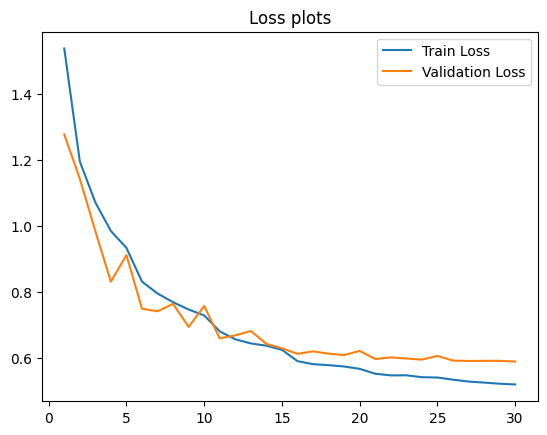

In [63]:
import matplotlib.pyplot as plt

plt.plot ( epoch_plot, train_loss_plot, label = 'Train Loss' )
plt.plot ( epoch_plot, val_loss_plot, label = 'Validation Loss' )
plt.title ( "Loss plots" )
plt.legend()
plt.show()